## 0. Import Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

INTERIM_DIR = Path("../data/interim")

modelling = pd.read_parquet(INTERIM_DIR / "modelling_dataset.parquet")

## 1. Dataset Structure 

In [2]:
assert modelling.index.is_unique

print(modelling.shape)
print(modelling.dtypes)

(200039, 35)
client_id                                     str
treatment_flg                               int64
target                                      int64
n_transactions                              int64
total_spending                            float64
avg_basket_value                          float64
median_basket_value                       float64
avg_items_per_basket                      float64
median_items_per_basket                   float64
n_stores                                    int64
loyalty_points_earned                     float64
loyalty_points_spent                      float64
prop_transactions_points_earned           float64
prop_transactions_points_spent            float64
first_purchase_date                datetime64[us]
last_purchase_date                 datetime64[us]
n_distinct_products                         int64
observation_period_days                   float64
observation_period_months                 float64
transactions_last_30d                

In [3]:
assert modelling["client_id"].is_unique
assert modelling["treatment_flg"].isin([0, 1]).all()
assert modelling["target"].isin([0, 1]).all()

### 1.1 Missing-Value Analysis 

In [5]:
missing = (
    modelling
    .isna()
    .sum()
    .to_frame("missing_n")
)

missing["missing_pct"] = 100 * missing["missing_n"] / len(modelling)

missing = (
    missing[missing["missing_n"] > 0]
    .sort_values("missing_pct", ascending=False)
    .round(2)
)

display(missing)

,missing_n,missing_pct
first_redeem_date,17546,8.77
issue_redeem_delay,17546,8.77
std_days_between_purchases,9292,4.65
mean_days_between_purchases,3820,1.91
median_days_between_purchases,3820,1.91
min_days_between_purchases,3820,1.91
max_days_between_purchases,3820,1.91


`first_redeem_date` represents the date and time when the customer first activated or "redeemed" their loyalty card by making a qualifying purchase. In ~9% of cases there wasn't a qualifying purchase made. </p>
`issue_redeem_delay` is an engineered feature from `first_issue_date` and `first_redeem_date`, inheriting the NaNs. </p>
- Need for imputation!

All missingness in interval features originate from clients with one or two purchases, where variability can't be estimated from single intervals, therefore undefined.  
- mean/median/min/max → defined with ≥2 transactions
- standard deviation → defined with ≥3 transactions
- No imputation needed!

### 1.2 Skewness Analysis 

In [6]:
numeric_cols = [cols for cols in modelling.select_dtypes(include="number").columns
                if cols != "treatment_flg" and cols != "target"]

skewness = (
    modelling[numeric_cols]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
    .round(2)
)

skewness["skew"] = modelling[numeric_cols].skew()

display(skewness.sort_values("skew", ascending=False).round(2))

,count,mean,std,min,median,max,skew
loyalty_points_spent,200039.0,79.85,133.90,0.00,39.00,10131.00,9.26
loyalty_points_earned,200039.0,78.82,99.26,0.00,49.60,8635.00,9.05
min_days_between_purchases,196219.0,2.44,9.02,0.00,0.14,113.00,7.30
spending_last_30d,200039.0,2631.86,2947.12,1.00,1791.00,133567.14,6.00
spending_last_60d,200039.0,4828.44,5198.73,1.00,3343.77,259456.00,5.46
total_spending,200039.0,8597.52,8914.60,1.04,6102.44,504490.38,5.40
spending_last_90d,200039.0,6893.15,7217.92,1.00,4865.00,373068.00,5.37
median_days_between_purchases,196219.0,7.34,10.42,0.00,4.09,113.00,4.60
mean_days_between_purchases,196219.0,9.33,10.49,0.00,6.22,113.00,4.10
prop_transactions_points_spent,200039.0,0.07,0.10,0.00,0.04,1.00,3.38


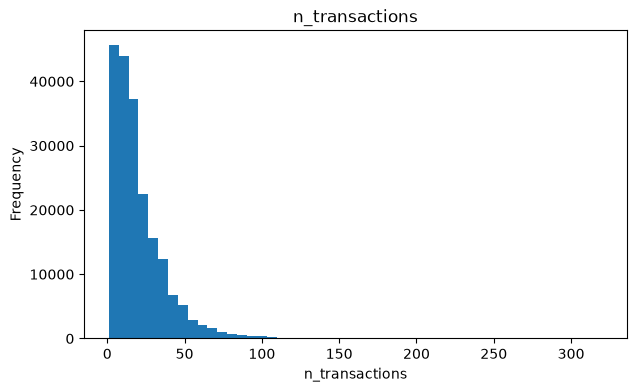

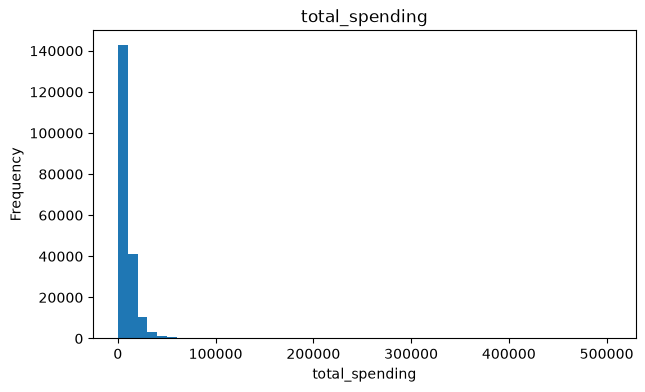

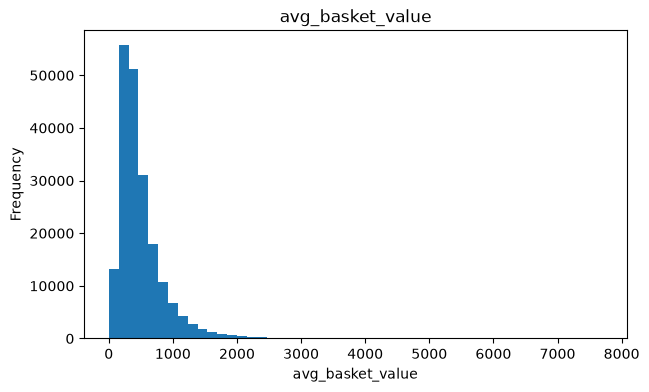

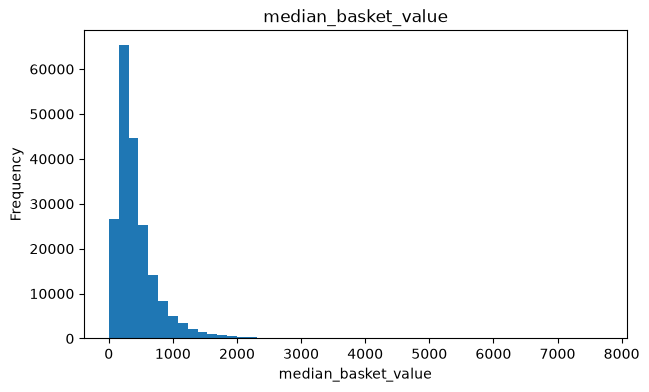

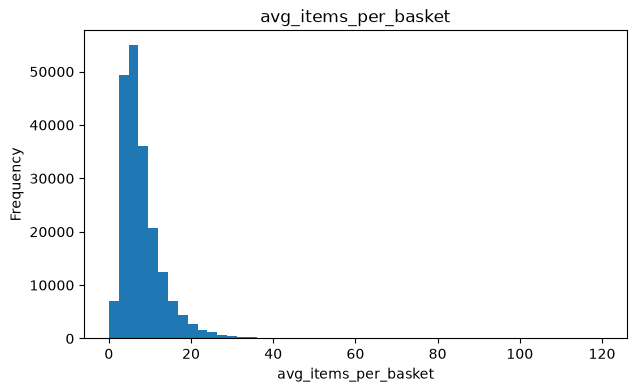

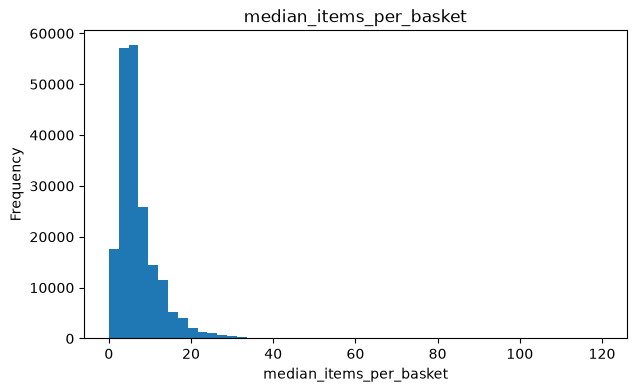

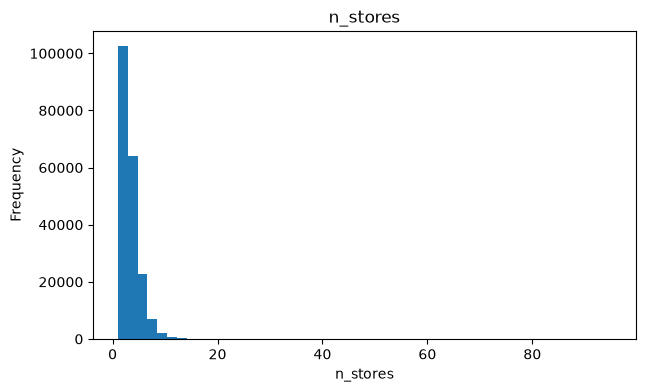

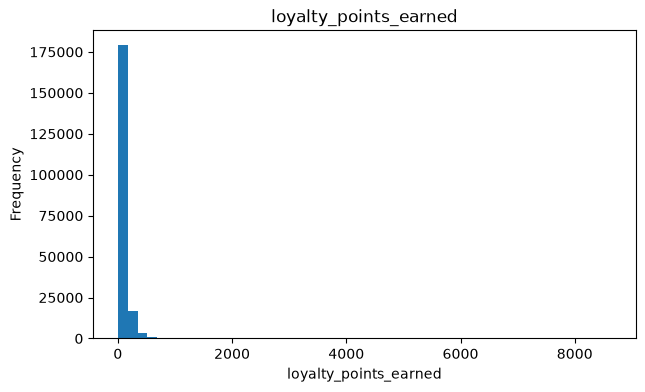

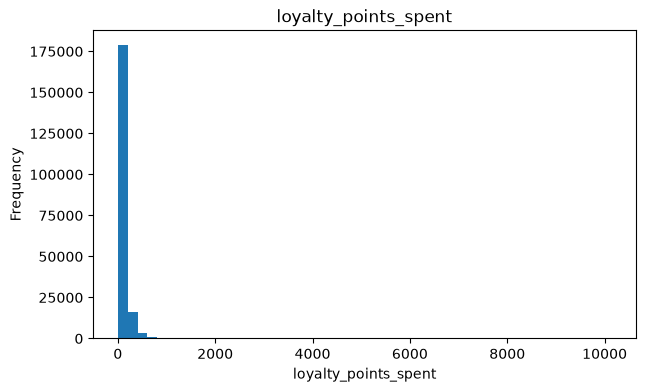

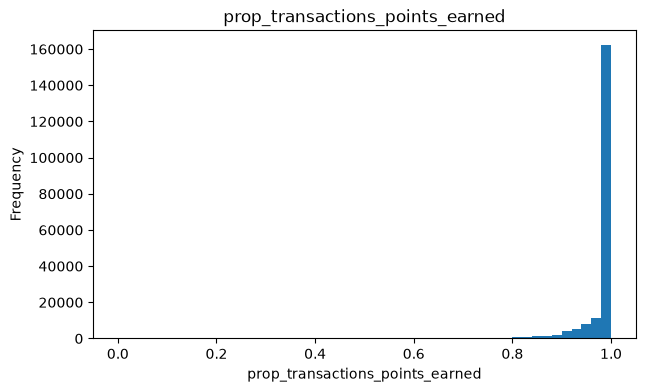

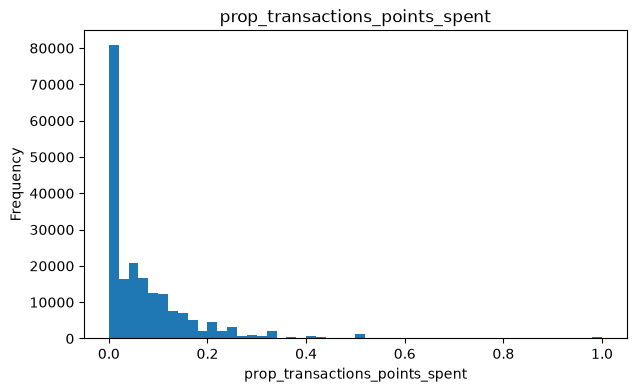

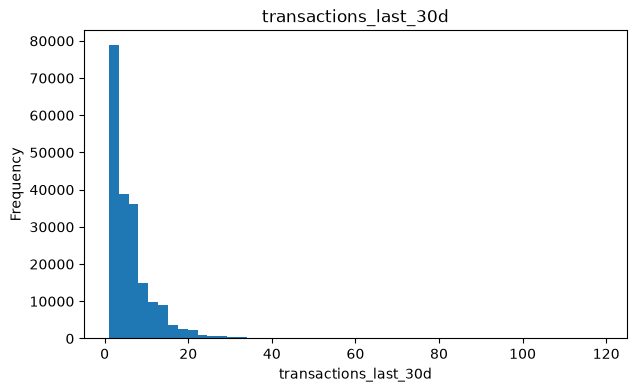

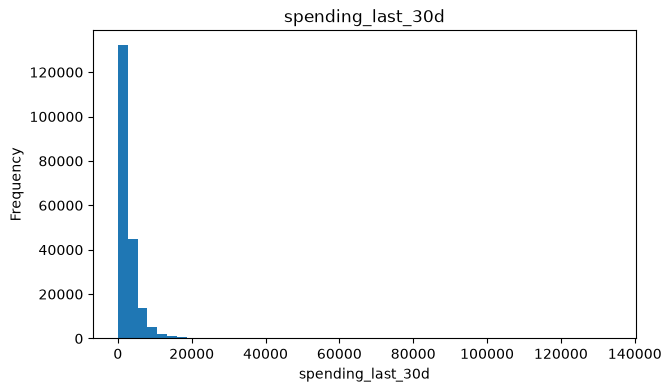

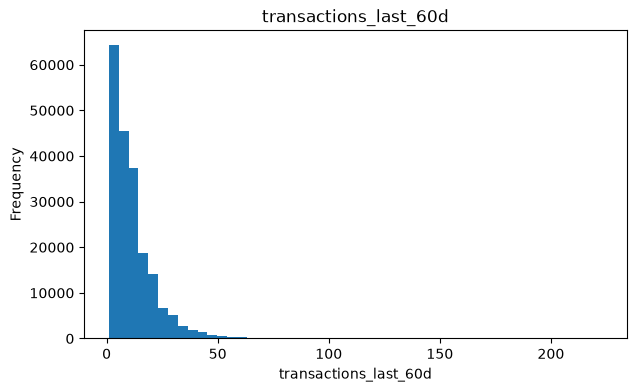

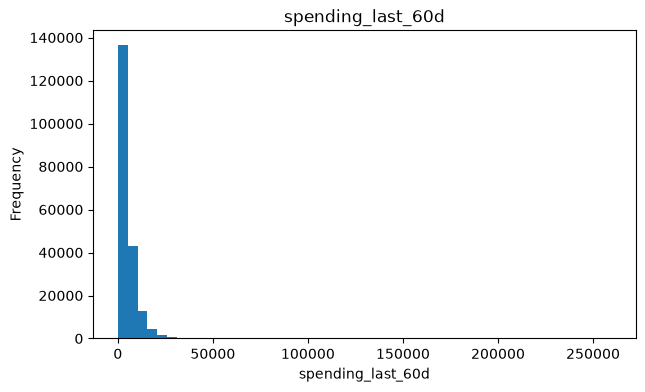

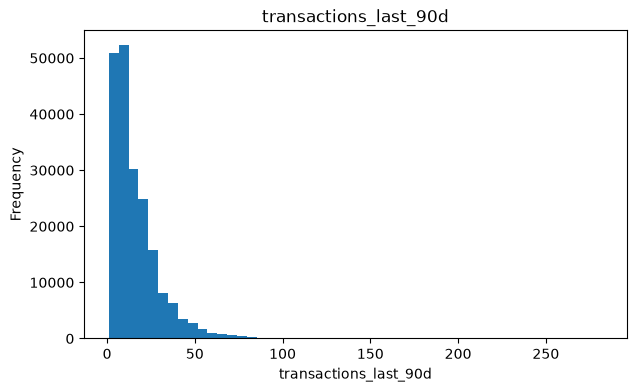

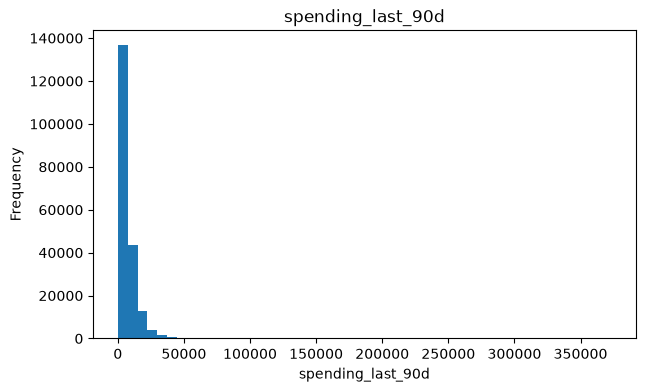

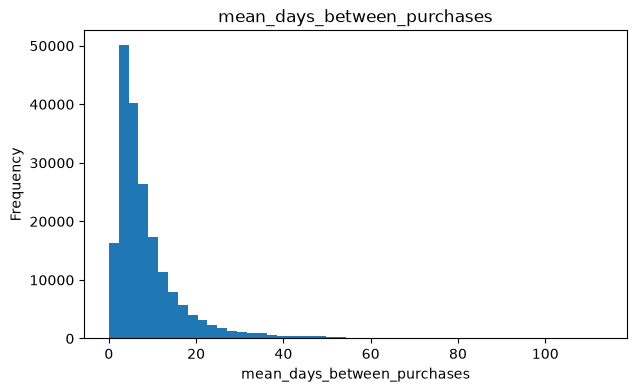

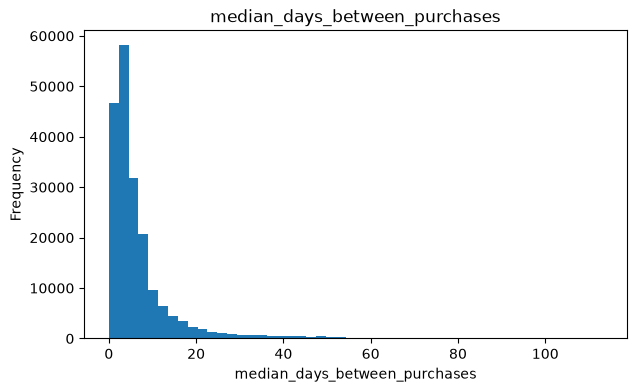

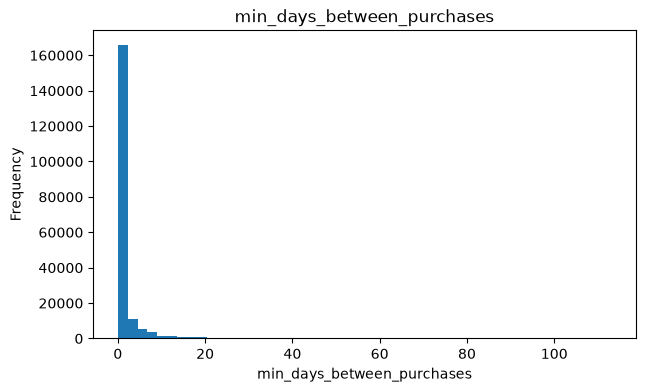

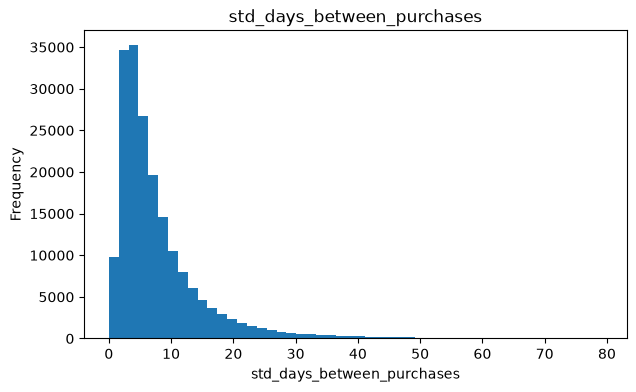

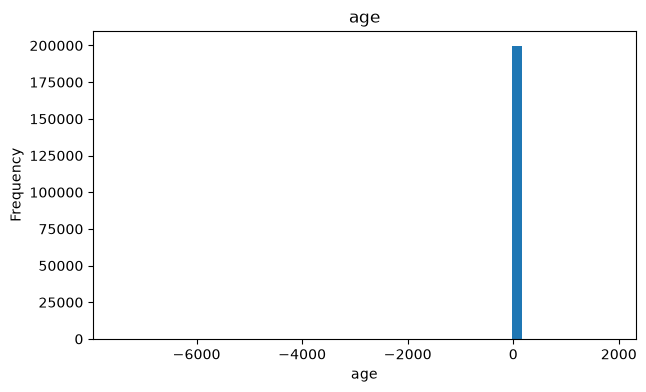

In [7]:
highly_skewed_cols = skewness[skewness["skew"].abs() > 2].index

for col in highly_skewed_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(modelling[col].dropna(), bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 1.2.1 Age

In [8]:
out_of_range_age = modelling["age"].lt(18) | modelling["age"].gt(100)

print(f"Clients with age < 18 or > 100: {out_of_range_age.sum()}")

Clients with age < 18 or > 100: 3236


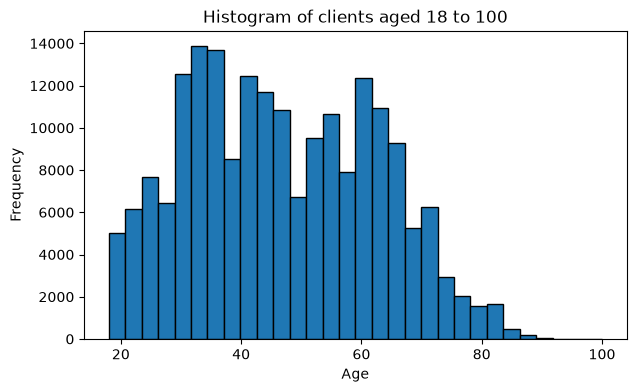

In [10]:
age_series = modelling[col].dropna()
valid_age = age_series.between(18, 100)

plt.figure(figsize=(7, 4))
plt.hist(age_series[valid_age], bins=30, edgecolor="black")
plt.title(f"Histogram of clients aged 18 to 100")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

As per X5 loyalty card policy, all card holders must be 18 and upwards. 
- ages <18 are disqualified 
- ages >100, possible but highly unlikely to participate in an loyalty program

**Consideration for elimination!**

### 1.2.2 Points Earned & Spent

In [13]:
n_unique_earned = modelling["prop_transactions_points_earned"].nunique(dropna=True)
print(f"Unique values in prop_transactions_points_earned: {n_unique_earned}")

n_unique_spent = modelling["prop_transactions_points_spent"].nunique(dropna=True)
print(f"Unique values in prop_transactions_points_spent: {n_unique_spent}")


Unique values in prop_transactions_points_earned: 985
Unique values in prop_transactions_points_spent: 1098


In [15]:
points = modelling[["prop_transactions_points_earned", "prop_transactions_points_spent"]]

bins = np.linspace(0, 1, 12)
labels = [f"{i / 10:.1f}" for i in range(11)]

unique_values_by_range = (
    points
    .melt(var_name="variable", value_name="value")
    .assign(
        bin=lambda df: pd.cut(
            df["value"], bins=bins, labels=labels, include_lowest=True
        )
    )
    .groupby(["variable", "bin"], observed=False)["value"]
    .nunique()
    .rename("unique_values")
    .unstack(fill_value=0)
)

display(unique_values_by_range)


bin,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
variable,,,,,,,,,,,
prop_transactions_points_earned,1,2,5,6,22,26,40,57,117,218,491
prop_transactions_points_spent,526,249,125,73,45,26,23,15,8,7,1


On average most transactions earn points for clients, therefore high concentration around 1.0. </p>
Equavalently on average no points are spent during transactions, therefore a high concentration around 0.0.



### 1.2.3 Issue-Redeem Delay

In [17]:
cols = [
    "client_id",
    "issue_redeem_delay",
    "first_issue_date",
    "first_redeem_date"
]

modelling.nlargest(20, "issue_redeem_delay")[cols]

,client_id,issue_redeem_delay,first_issue_date,first_redeem_date
47724,3cd00de0c7,935.570451,2017-04-17 22:06:05,2019-11-09 11:47:32
121005,9b03f0e6e8,933.047789,2017-04-17 11:55:23,2019-11-06 13:04:12
14986,1340280732,932.666829,2017-04-28 21:24:00,2019-11-17 13:24:14
157927,ca53340bd3,930.036725,2017-04-15 12:50:52,2019-11-01 13:43:45
116736,957b39b140,929.918785,2017-04-16 13:05:00,2019-11-02 11:08:03
45186,397c3d3e8a,929.275370,2017-04-18 10:41:43,2019-11-03 17:18:15
19391,18e2e41f20,929.150880,2017-04-18 12:12:24,2019-11-03 15:49:40
100762,80be8a5c25,929.143553,2017-04-21 16:59:38,2019-11-06 20:26:21
148147,bdd5ad30d9,928.211933,2017-04-16 13:32:49,2019-10-31 18:38:00
85636,6d4e90b1c8,925.876470,2017-05-01 15:24:50,2019-11-13 12:26:57


In [21]:
modelling.loc[
    modelling["issue_redeem_delay"] < 0,
    [
        "client_id",
        "first_issue_date",
        "first_redeem_date",
        "issue_redeem_delay"
    ]
].sort_values("issue_redeem_delay")

,client_id,first_issue_date,first_redeem_date,issue_redeem_delay
946,01440dcc9f,2018-11-09 13:50:09,2018-09-27 17:35:20,-42.843623
43697,379ee75556,2018-09-23 23:37:21,2018-09-23 23:32:00,-0.003715
126283,a1e30dace1,2018-12-21 16:17:18,2018-12-21 16:12:19,-0.003461
78983,64bf2981e6,2019-02-06 16:49:55,2019-02-06 16:45:01,-0.003403
139738,b307ca85a1,2019-01-31 19:23:10,2019-01-31 19:20:16,-0.002014
...,...,...,...,...
99480,7f0c2d3a2b,2019-02-06 20:16:18,2019-02-06 20:16:16,-0.000023
161869,cf629311de,2018-07-21 11:11:14,2018-07-21 11:11:13,-0.000012
185366,ed4d56c45b,2019-01-15 20:49:06,2019-01-15 20:49:05,-0.000012
135492,adb19a06cb,2018-12-22 17:38:37,2018-12-22 17:38:36,-0.000012


Card issue/redemption exceeds the observational period in the transactional data, therefore, the **very high delays are valid**. </p>
Negative delays signify data problems, since redemption took place before issue. Where difference is within minutes/seconds it can be considered the same event. For one singular observation with 42 days difference it's a clear data error.
- **Needs reengineering!**

### 1.2.4  Number of Stores

In [22]:
modelling.nlargest(30, "n_stores")[["client_id", "n_stores", "n_transactions", "observation_period_months"]]

,client_id,n_stores,n_transactions,observation_period_months
183104,ea576925b1,95,132,3.815553
190844,f43017e865,84,100,3.385709
88584,710cd5a198,57,65,3.658416
136943,af81fa3385,53,88,3.826579
109173,8b9de0afcc,49,101,3.443054
9803,0c89dd7451,46,52,3.383593
16985,15d8ea4fae,40,62,3.808459
57340,49281b577d,40,150,3.813318
101794,821316bc69,40,51,3.144961
10546,0d7e205b30,37,71,3.812473


All plausible values!

### 1.2.5 Basket Variables

In [67]:
modelling.nlargest(20, "avg_basket_value")[
    ["client_id", "n_transactions", "avg_basket_value", "median_basket_value",
     "avg_items_per_basket", "median_items_per_basket"]
]

,client_id,n_transactions,avg_basket_value,median_basket_value,avg_items_per_basket,median_items_per_basket
151487,c21c49365e,1,7694.000000,7694.000,75.000000,75.0
197649,fced39426e,6,7201.611667,6701.400,71.666667,76.0
75867,60d89a4e2c,2,7120.590000,7120.590,92.500000,92.5
45966,3a88c77d44,5,6585.800000,7152.000,95.800000,93.0
62869,503fb22604,1,6407.000000,6407.000,77.000000,77.0
48265,3d84e13468,2,6398.280000,6398.280,66.500000,66.5
64173,51e7d3ac88,1,6263.000000,6263.000,117.000000,117.0
189464,f278b253ec,8,6239.768750,6275.180,82.750000,83.0
59616,4c295e726c,3,6019.193333,1419.430,36.666667,12.0
150005,c04b39df70,7,5862.958571,6538.540,62.714286,61.0


These don't immediately look like data errors, just clients with very large baskets.
- Considering log transformations for Arm 1!

## 1.3 Outlier Analysis

In [23]:
outlier_summary = []

for col in numeric_cols:
    q1 = modelling[col].quantile(0.25)
    q3 = modelling[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_out = ((modelling[col] < lower) | (modelling[col] > upper)).sum()

    outlier_summary.append(
        [col, n_out, 100 * n_out / len(modelling)]
    )

outliers = pd.DataFrame(
    outlier_summary,
    columns=["feature", "outlier_n", "outlier_pct"]
)

display(outliers.sort_values("outlier_pct", ascending=False).round(2))

,feature,outlier_n,outlier_pct
9,prop_transactions_points_earned,41201,20.60
22,min_days_between_purchases,29787,14.89
13,observation_period_months,19649,9.82
12,observation_period_days,19649,9.82
21,median_days_between_purchases,18575,9.29
20,mean_days_between_purchases,14908,7.45
7,loyalty_points_earned,14391,7.19
24,std_days_between_purchases,13407,6.70
8,loyalty_points_spent,12383,6.19
15,spending_last_30d,12199,6.10


Confirms findings in the skewness analysis. 

## 1.4 Categorical Variables

In [24]:
categorical_cols = [
    col for col in modelling.select_dtypes(include=["object", "category", "bool"]).columns
    if col != "client_id"
]

for col in categorical_cols:

    print(f"\n{col}")
    print(modelling[col].value_counts(dropna=False))
    print("Unique:", modelling[col].nunique(dropna=False))


gender
gender
U    92832
F    73696
M    33511
Name: count, dtype: int64
Unique: 3


/var/folders/x7/047n0r0d3h33lrf4wxq3gm4r0000gn/T/ipykernel_35590/3800019849.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in modelling.select_dtypes(include=["object", "category", "bool"]).columns


Lable Encoding needed!

## 2. RCT Inspection 

In [25]:
modelling.groupby("treatment_flg")["target"].agg(
    ["count", "sum", "mean"]
).round(4)

,count,sum,mean
treatment_flg,,,
0,100058,60363,0.6033
1,99981,63639,0.6365


In [26]:
pd.crosstab(
    modelling["treatment_flg"],
    modelling["target"],
    normalize="index",
).round(4)

target,0,1
treatment_flg,,
0,0.3967,0.6033
1,0.3635,0.6365


In [27]:
conversion = (
    modelling
    .groupby("treatment_flg")["target"]
    .mean()
)

ate = conversion[1] - conversion[0]

print(ate.round(4))

0.0332


In [28]:
treatment = modelling["treatment_flg"]

balance = []

for col in numeric_cols:
    balance.append({
        "feature": col,
        "control_mean": modelling.loc[treatment == 0, col].mean(),
        "treated_mean": modelling.loc[treatment == 1, col].mean(),
        "control_median": modelling.loc[treatment == 0, col].median(),
        "treated_median": modelling.loc[treatment == 1, col].median(),
    })

balance = pd.DataFrame(balance)

display(balance)

,feature,control_mean,treated_mean,control_median,treated_median
0,n_transactions,20.056097,20.185595,15.000000,15.000000
1,total_spending,8569.366066,8625.699528,6070.105000,6135.440000
2,avg_basket_value,494.763026,496.804204,393.856636,394.096875
3,median_basket_value,431.317976,433.276408,331.000000,330.500000
4,avg_items_per_basket,7.996053,8.020129,6.623975,6.656250
5,median_items_per_basket,7.060975,7.082996,6.000000,6.000000
6,n_stores,2.917338,2.924046,2.000000,2.000000
7,loyalty_points_earned,78.609083,79.030284,49.500000,49.600000
8,loyalty_points_spent,79.726339,79.976596,39.000000,39.000000
9,prop_transactions_points_earned,0.983026,0.983138,1.000000,1.000000


In [29]:
gender_treatment = pd.crosstab(
    modelling["gender"],
    modelling["treatment_flg"],
    normalize="index"
).rename(columns={0: "control_proportion", 1: "treated_proportion"})

display(gender_treatment.round(4))

treatment_flg,control_proportion,treated_proportion
gender,,
F,0.4991,0.5009
M,0.5009,0.4991
U,0.5008,0.4992


RCT well-balanced!

## 3. Correlation Analysis

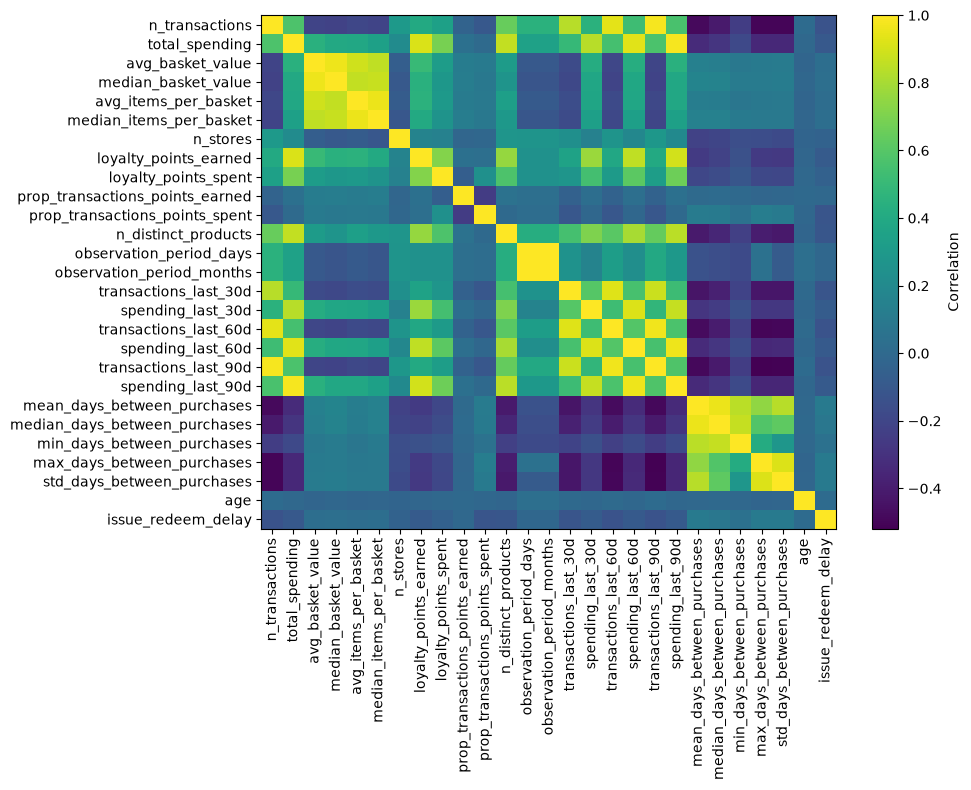

In [30]:
corr = modelling[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.tight_layout()
plt.show()

In [31]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={
        "level_0": "feature_1",
        "level_1": "feature_2",
        0: "correlation"
    })
)

display(
    high_corr[
        high_corr["correlation"].abs() > 0.8
    ].sort_values(
        "correlation",
        key=abs,
        ascending=False
    )
)

,feature_1,feature_2,correlation
337,observation_period_days,observation_period_months,1.000000
18,n_transactions,transactions_last_90d,0.981695
46,total_spending,spending_last_90d,0.981198
450,transactions_last_60d,transactions_last_90d,0.968859
478,spending_last_60d,spending_last_90d,0.963302
57,avg_basket_value,median_basket_value,0.960780
561,mean_days_between_purchases,median_days_between_purchases,0.958217
113,avg_items_per_basket,median_items_per_basket,0.955239
16,n_transactions,transactions_last_60d,0.936272
44,total_spending,spending_last_60d,0.934131


Highest correlation btw related engineered features and features used as base.
- During modelling a preselection of X is needed!

## 4. Final Preprocessing Decision Overview

| Feature           | Type        | Missing | Skewness | Outliers | Decision           | Rationale |
| ----------------- | ----------- | ------: | -------: | -------: | ------------------ | --------- |
| age               | numeric     |    -    |  **-85.25**  |    **0.29%**   | Restrict btw 18 - 100; invalid → NaN, then impute | Extreme values are clearly data-quality issues, not genuine heterogeneity. |
| gender            | categorical | - | - | - | Lable Encode | 3 categories |
| n_transactions    | count | - | 2.36 | 4.51% | Log-transformation | Count variables have typically long right tails |
| total_spending    | count       | - | 5.4 | 5.74% | Log-transformation | Monetary variables are naturally right-skewed; large spenders may be genuine |
| avg_basket_value  | numeric   |     -   | 2.99 | 5.88% | Log-transformation | Count variable with substantial upper tail |
| median_basket_value | numeric     |   -     | 3.13 | 6.09% | Log-transformation | Count variable with substantial upper tail |
| avg_items_per_basket     | numeric     |    -    | 2.91 | 5.2% | Log-transformation | Count variable with substantial upper tail |
| median_items_per_basket  | numeric     |    -    | 3.13 | 5.25% | Log-transformation | Count variable with substantial upper tail |
| n_stores          | count  |     -   | 3.13 | 2.98% | Log-transformation | Count variable with substantial upper tail |
| loyalty_points_earned | numeric | - | **9.05** | **7.19%** | Log-transformation | Strongly skewed, non-negative, and zeros are meaningful. |
| loyalty_points_spent| numeric | - | **9.26** | **6.19%** | Log-transformation | Strongly skewed, non-negative, and zeros are meaningful|
| prop_transactions_points_earned | numeric | - | **-7.97** | 20.6% | Leave unchanged; Huge mass near 1, bounded [0,1] | Skewness is driven by its bounded/structural distribution |
| prop_transactions_points_spent  | numeric | - | **3.38** | 4.58% | Leave unchanged; 0/low-heavy, bounded [0,1] | This is a proportion, not a conventional continuous skewed variable |
| first_purchase_date | datetime | - | - | - | - | - |
| last_purchase_date  | datetime | - | - | - | - | - |
| n_distinct_products | count | - | 1.85 | 3.52% | probably Log-transformation| Moderate right skew; transformation is reasonable for stability |
| observation_period_days | numeric | - | -1.73 | 9.82% | Leave unchanged | No need to normalize this variable|
| observation_period_months | numeric | - | -1.73 | 9.82% | Leave unchanged | No need to normalize this variable|
| transactions_last_30d | count | - | 2.66 | 4.3% | Log-transformation | Count variables have long right tails |
| spending_last_30d | numeric | - | 6.0| 6.1% | Log-transformation | Strongly right-skewed durations|
| transactions_last_60d | count | - | 2.46 | 4.64% | Log-transformation | Count variables have long right tails |
| spending_last_60d | numeric | - | 5.46 | 6.05% | Log-transformation | Strongly right-skewed durations|
| transactions_last_90d | count | - | 2.39 | 4.73% | Log-transformation | Count variables have long right tails |
| spending_last_90d | numeric | - | 5.37 | 5.9% | Log-transformation | Strongly right-skewed durations |
| mean_days_between_purchases | numeric | 1.91% | - | 7.45%| Log-transformation; Missingness structural, no imputation | Originate from clients with 1 or 2 purchses, where Variability can't be estimated.|
| median_days_between_purchases | numeric | 1.91% | 4.6 | 9.29% | Log-transformation; Missingness structural, no imputation | Strongly right-skewed durations |
| min_days_between_purchases | numeric | 1.91% | 7.3 | 14.89% | Log-transformation; Missingness structural, no imputation | Strongly right-skewed durations |
| max_days_between_purchases | numeric | 1.91% | 1.53 | 4.77% | Log-transformation; Missingness structural, no imputation | Strongly right-skewed durations |
| std_days_between_purchases | numeric | 4.65% | 2.91 | 6.7% | Log-transformation; Missingness structural, no imputation | Strongly right-skewed durations |
| first_issue_date | datetime | - | - | - | - | - |
| first_redeem_date | datetime | 8.77% | - | - | Imputation | Needed for Arm 1|
| issue_redeem_delay | numeric | 8.77% | 1.36 | 3.75% | Re-engineer first → impute | Tail reflects the underlying date structure |







